In [1]:
# reload
%load_ext autoreload
%autoreload 2

In [2]:
import os
import time
import pandas as pd
import pprint
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle

pp = pprint.PrettyPrinter(indent=4)

from graph import (
    split_graph,
    merge_single_edge,
    construct_graph_from_transitions,
    get_mm_nodes_with_cycle,
)
from project import Manager

# Functions

- load_trace_data: load trace_dict, trace_size_dict, trace_hash_ordered
  - trace_dict: {trace_hash: [trace]}
  - trace_size_dict: {trace_hash: trace_size}
  - trace_hash_ordered: [trace_hash]
- get_statistics: return the min, max, and average of the trace lengths
- construct_cfg: construct the control flow graph (CFG) from traces
- node_reduction: node reduction mechanism for discovery probability analysis

In [3]:
def load_trace_data(subject):
    # Load the trace_dict and trace_size_dict
    trace_dict = json.load(open(f"../data/{subject}/trace_dict.json"))
    trace_size_dict = json.load(open(f"../data/{subject}/trace_size_dict.json"))
    trace_hash_ordered = sorted(
        trace_size_dict.keys(), key=lambda x: trace_size_dict[x]
    )
    return trace_dict, trace_size_dict, trace_hash_ordered

In [4]:
def get_statstics(subject, trace_dict, trace_hash_ordered):
    len_sum = 0
    trace_cnt = 0
    min_trace = 100000000
    max_trace = 0
    for trace_hash in trace_hash_ordered[::-1]:
        transition_df = pd.read_csv(
            f"../data/{subject}/unique-transition/{trace_hash}.csv"
        )
        l = transition_df["taken"].value_counts()[1] + 1
        len_sum += l * len(trace_dict[trace_hash])
        trace_cnt += len(trace_dict[trace_hash])
        min_trace = min(min_trace, l)
        max_trace = max(max_trace, l)
    print(f"Average trace length: {len_sum/trace_cnt}")
    print(f"Min trace length: {min_trace}")
    print(f"Max trace length: {max_trace}")

In [5]:
def construct_cfg(subject, trace_hash_ordered):
    start_time = time.time()
    G = construct_graph_from_transitions(
        trace_ids=trace_hash_ordered,
        transition_dfs=[
            pd.read_csv(f"{subject}/unique-transition/{trace_hash}.csv")
            for trace_hash in trace_hash_ordered
        ],
    )
    print(
        f"|   Constructed graph with traces; Size: {len(G.nodes)} nodes, {len(G.edges)} edges; Time: {time.time() - start_time:.2f}s"
    )
    print("|   Merge single edge")
    start_time = time.time()
    G_simple = merge_single_edge(G)
    print(
        f"|   Merged single edge; Size: {len(G_simple.nodes)} nodes, {len(G_simple.edges)} edges; Time: {time.time() - start_time:.2f}s"
    )
    print("|   Split graph")
    start_time = time.time()
    Gs = split_graph(G_simple)
    print(
        f"|   Splitted graph; Number of clusters: {len(Gs)}; Time: {time.time() - start_time:.2f}s"
    )
    return Gs

In [6]:
def node_reduction(subject, Gs):
    start_time = time.time()
    mm_nodes_merged = set()
    for idx, G_cluster in enumerate(Gs, 1):
        print(f"mm nodes for G_cluster {idx}")
        with open(f"{subject}/debug.txt", "a") as f:
            mm_nodes_merged |= get_mm_nodes_with_cycle(G_cluster)
        print(
            f"Number of MM nodes: {len(mm_nodes_merged)}; Time: {time.time() - start_time:.2f}s"
        )
    print(
        f"Done. {len(mm_nodes_merged)} mm nodes found; Time: {time.time() - start_time:.2f}s"
    )
    mm_nodes = {
        mm_node_merged.split("\n")[0] for mm_node_merged in mm_nodes_merged
    }
    json.dump(
        list(mm_nodes),
        open(f"../data/{subject}/node-reduced.json", "w"),
        indent=4,
    )
    return mm_nodes

# Node reduction mechanism (example subject: Delta)

## Load trace data & get trace data statistics

In [7]:
subject = "delta"
trace_dict, trace_size_dict, trace_hash_ordered = load_trace_data(subject)
print(f"Number of unique traces: {len(trace_hash_ordered)}")
print(
    f"Number of total traces: {sum(len(trace_dict[trace_hash]) for trace_hash in trace_hash_ordered)}"
)
get_statstics(subject, trace_dict, trace_hash_ordered)

Number of unique traces: 197
Number of total traces: 217
Average trace length: 9939.345622119816
Min trace length: 5
Max trace length: 75848


## Load/compute the node reduction

In [8]:
remake_mm_nodes = False
if not remake_mm_nodes and os.path.exists(
    f"../data/{subject}/node-reduced.json"
):
    mm_nodes = json.load(open(f"../data/{subject}/node-reduced.json"))
    mm_nodes = set(mm_nodes)
    print(f"Loaded {len(mm_nodes)} mm nodes.")
else:
    Gs = construct_cfg(subject, trace_hash_ordered)
    mm_nodes = node_reduction(subject, Gs)

Loaded 29939 mm nodes.


## Check how much decrease in the number of mm_nodes

### Load/construct project manager

The project manager is used to easily sample the traces and compute the discovery probability estimates.

In [9]:
remake_manager = False
if not remake_manager and os.path.exists(f"../data/{subject}/manager.pkl"):
    manager = pickle.load(open(f"../data/{subject}/manager.pkl", "rb"))
    # compute the memory usage of the manager object
else:
    manager = Manager(subject, trace_dict, trace_size_dict)
    # save the manager object as a pickle file
    pickle.dump(manager, open(f"../data/{subject}/manager.pkl", "wb"))

Loading trace_dict...
Loading trace_size_dict...
Calculating trace_probability_dict...
Calculating addr_dict...
Processing traces...


### Ratio of the reduction

In [12]:
print(
    f"Ratio = {len(mm_nodes)} / {len(manager.nodes)} = {len(mm_nodes) / len(manager.nodes):.2f}"
)

Ratio = 29939 / 135755 = 0.22


# Sampling simulation (Fig. 5)

In [19]:
num_sample = sum(len(traces) for _, traces in manager.thash2traces.items())
num_repetition = 20
dfs = []
for rep_i in range(num_repetition):
    print(f"Repetition {rep_i}", end="\r", flush=True)
    start_time = time.time()
    tracehash_smp = manager.sample_tracehash(num_sample)
    missing_mass = []
    mm_good_turing = []
    mm_struct_original = []
    mm_struct_reduced = []
    for i in range(0, num_sample + 1):
        print(
            f"Repetition {rep_i}, Iteration {i}/{num_sample}",
            end="\r",
            flush=True,
        )
        tracehash_subsmp = tracehash_smp[:i]
        missing_mass.append(manager.compute_missing_mass(tracehash_subsmp))
        mm_good_turing.append(manager.good_turing(tracehash_subsmp))
        mm_struct_original.append(manager.struct_original(tracehash_subsmp))
        mm_struct_reduced.append(
            manager.struct_original(tracehash_subsmp, node_set=mm_nodes)
        )
    df_i = pd.DataFrame(
        {
            "rep_i": rep_i,
            "num_samples": list(range(num_sample + 1)),
            "missing_mass": missing_mass,
            "good_turing": mm_good_turing,
            "struct_original": mm_struct_original,
            "struct_reduced": mm_struct_reduced,
        }
    )
    dfs.append(df_i)
    print(f"Repetition {rep_i} done; Time: {time.time() - start_time:.2f}s")

Repetition 0 done; Time: 5.72s7
Repetition 1 done; Time: 5.45s7
Repetition 2 done; Time: 5.68s7
Repetition 3 done; Time: 6.01s7
Repetition 4 done; Time: 5.84s7
Repetition 5 done; Time: 5.60s7
Repetition 6 done; Time: 5.84s7
Repetition 7 done; Time: 5.83s7
Repetition 8 done; Time: 5.66s7
Repetition 9 done; Time: 5.79s7
Repetition 10 done; Time: 5.99s7
Repetition 11 done; Time: 5.62s7
Repetition 12 done; Time: 5.87s7
Repetition 13 done; Time: 5.69s7
Repetition 14 done; Time: 5.63s7
Repetition 15 done; Time: 5.95s7
Repetition 16 done; Time: 5.91s7
Repetition 17 done; Time: 5.58s7
Repetition 18 done; Time: 5.57s7
Repetition 19 done; Time: 5.80s7


In [20]:
df_total = pd.concat(dfs)

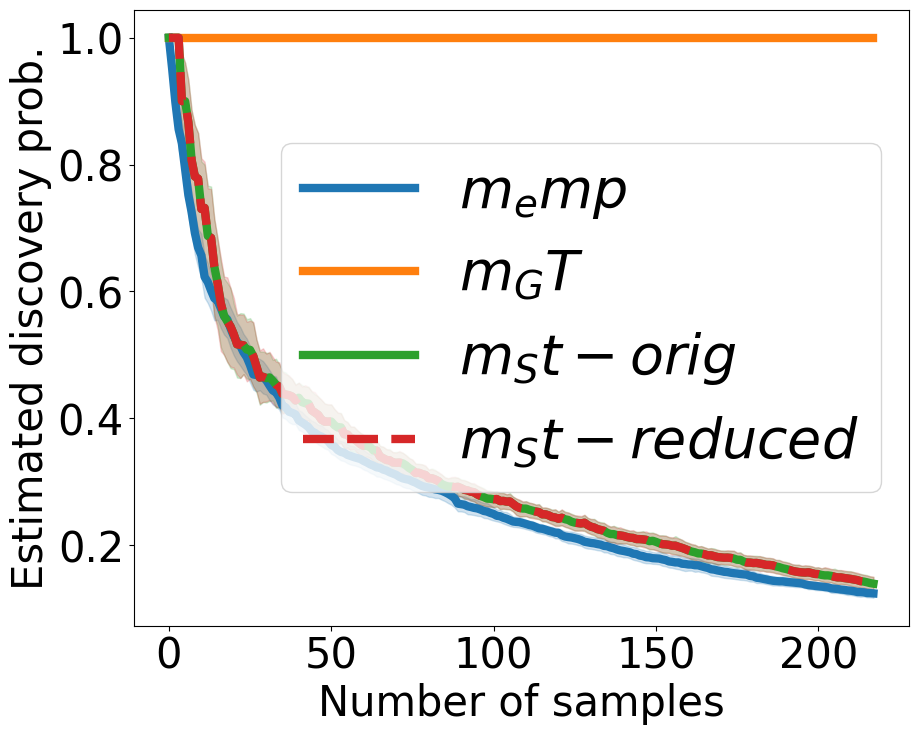

In [25]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.lineplot(
    data=df_total,
    x="num_samples",
    y="missing_mass",
    ax=ax,
    label="$m_emp$",
    linewidth=6,
)
sns.lineplot(
    data=df_total,
    x="num_samples",
    y="good_turing",
    ax=ax,
    label="$m_GT$",
    linewidth=6,
)
sns.lineplot(
    data=df_total,
    x="num_samples",
    y="struct_original",
    ax=ax,
    label="$m_St-orig$",
    linewidth=6,
)
sns.lineplot(
    data=df_total,
    x="num_samples",
    y="struct_reduced",
    ax=ax,
    linestyle="--",
    label="$m_St-reduced$",
    linewidth=6,
)
ax.set_xlabel("Number of samples", fontsize=30)
ax.set_ylabel("Estimated discovery prob.", fontsize=30)
ax.tick_params(axis="both", labelsize=30)
# ax.get_legend().remove()
ax.legend(fontsize=40)
plt.savefig(
    "../figs/delta.pdf",
    bbox_inches="tight",
)
plt.show()